# 06 - Segmentation

This notebook performs segmentation on the preprocessed data.

HDBSCAN is used for clustering because it can discover groups without requiring the number of clusters to be specified in advance. It is well-suited for identifying well-separated segments in the data rather than assuming fixed cluster shapes or densities. It is also robust to noise, as it can label low-density points as outliers, which is useful in settings where not all observations are expected to belong to a clear cluster structure.

This notebook outlines the segmentation pipeline and the rationale behind the preprocessing and modeling choices.

## Imports

In [1]:
from collections import Counter
import sys

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display, HTML

sys.path.append("../src")

from my_datasets import census
from my_datasets import dataframe_utils
import ml_utils
from ml_utils import model_pipelines
from ml_utils import visualizations

## Helper Functions

### `train_segmentation_model`

Reusable utility function that loads a previously trained model from disk if available. If no saved model exists, it trains a new model using the full dataset, saves it for future reuse, and then returns the fitted model.

In [2]:
def train_segmentation_model(
    df,
    categorical_columns,
    numeric_columns,
    remove_niu=False,
):
    filename = (
        "segmentation_niu_removed.joblib" if remove_niu
        else "segmentation.joblib"
    )
    
    try:
        segmentation_pipeline = census.load_model(filename)
        display(segmentation_pipeline)
        print("Loaded pretrained segmentation model.")
    except FileNotFoundError:
        print("No pretrained segmentation model found.")
        segmentation_pipeline = model_pipelines.get_segmentation_models(
            categorical_columns=categorical_columns,
            numeric_columns=numeric_columns,
            remove_niu=remove_niu,
            dimensionality_reduction="umap",
            n_components=20,
            select="hdbscan"
        )
        display(segmentation_pipeline)
        
        import time
        from datetime import timedelta
        
        start = time.perf_counter()
        segmentation_pipeline.fit(df)
        end = time.perf_counter()
        
        elapsed = end - start
        print(f"  {timedelta(seconds=elapsed)}")
    
        census.save_model(segmentation_pipeline, filename)

    return segmentation_pipeline

### `save_figure`

In [3]:
def save_figure(fig, feature):
    filename = f"{feature.replace(' ', '_')}.png"
    census.save_figure(fig, filename)

### `plot_and_save_numeric_feature`

In [4]:
def plot_and_save_numeric_feature(
	data_df,
	feature,
	weight_column,
	cluster_labels,
	save_func,
	figsize=(12.8, 4.8),
	cluster_colors="hsv",
	include_overall=True,
	clip_outliers=False,
	legend_loc="upper left",
	bbox_to_anchor=(1.02, 1.0),
	legend_ncol=1,
	frameon=True,
	columnspacing=0.8,
	handletextpad=0.4,
	borderaxespad=0,
	title_prefix=None,
	xlabel="Cluster",
	ylabel=None,
	show=True,
	save=True
):
	fig, ax = plt.subplots(figsize=figsize)

	visualizations.plot_cluster_violins(
		df=data_df,
		feature=feature,
		cluster_assignments=data_df["cluster"],
		weight_column=weight_column,
		clusters=None,
		cluster_labels=cluster_labels,
		cluster_colors=cluster_colors,
		include_overall=include_overall,
		clip_outliers=clip_outliers,
		title=f"{feature} Distribution by Cluster" if title_prefix is None else f"{title_prefix}: {feature}",
		xlabel=xlabel,
		ylabel=ylabel,
		ax=ax
	)

	if ax.get_legend() is not None:
		ax.legend(
			title="Cluster",
			loc=legend_loc,
			bbox_to_anchor=bbox_to_anchor,
			ncol=legend_ncol,
			frameon=frameon,
			columnspacing=columnspacing,
			handletextpad=handletextpad,
			borderaxespad=borderaxespad
		)

	if show:
		plt.show()

	if save:
		filename = f"{feature.replace(' ', '_')}.png"
		save_func(fig, filename)

## Segmentation Features

Rather than using the full feature space, segmentation is performed on a subset of the features designed to capture the following aspects of the data:

* demographic identity
* socioeconomic context
* economic outcomes

This was done to reduce noise, improve clustering quality, and produce segments that are more stable and interpretable for downstream use.

In [5]:
demographic_features = [
    "age",
    "sex",
    "race",
    "education",
    "country of birth self"
]

economic_features = [
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks"
]

socioeconomic_features = [
    "marital stat",
    "class of worker",
    "major occupation code",
    "major industry code",
    "family members under 18"
]

final_features = (
    demographic_features
    + economic_features
    + socioeconomic_features
)

## Data Loading and Inspection

The cleaned, processed dataset is loaded into a dataframe and basic inspection is performed to verify that it has been loaded correctly.

The target and sample weight columns are identified, along with the numeric-categorical features.

In [6]:
data_df = census.load_processed_dataframe("clean_data.csv", header=0, verbose=False)

dataframe_utils.print_dataframe_info(data_df)

target_column = census.get_target_feature()
weight_column = census.get_sample_weights_feature()

numeric_categorical_features = census.get_numeric_categorical_features()

# # subsample for code testing
# from sklearn.model_selection import train_test_split
# data_df, _ = train_test_split(
#     data_df,
#     train_size=1000,
#     stratify=data_df[target_column],
#     random_state=42,
# )
# data_df = data_df.reset_index(drop=True)
# dataframe_utils.print_dataframe_info(data_df)

DataFrame Memory Usage: 362.04 MB


,dtype,count,non_null,null_count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,int64,199523,199523,0,NaN,NaN,NaN,34.494199,22.310895,0.0,15.0,33.0,50.0,90.0
class of worker,str,199523,199523,0,9,Not in universe,100245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
detailed industry recode,int64,199523,199523,0,NaN,NaN,NaN,15.35232,18.067129,0.0,0.0,0.0,33.0,51.0
detailed occupation recode,int64,199523,199523,0,NaN,NaN,NaN,11.306556,14.454204,0.0,0.0,0.0,26.0,46.0
education,str,199523,199523,0,17,High school graduate,48407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wage per hour,int64,199523,199523,0,NaN,NaN,NaN,55.426908,274.896454,0.0,0.0,0.0,0.0,9999.0
enroll in edu inst last wk,str,199523,199523,0,3,Not in universe,186943,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital stat,str,199523,199523,0,7,Never married,86485,NaN,NaN,NaN,NaN,NaN,NaN,NaN
major industry code,str,199523,199523,0,24,Not in universe or children,100684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
major occupation code,str,199523,199523,0,15,Not in universe,100684,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199518,87,Not in universe,0,0,7th and 8th grade,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,White,All other,Male,Not in universe,Not in universe,Not in labor force,0,0,0,Joint both 65+,Not in universe,Not in universe,Householder,Householder,955.27,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,Canada,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
199519,65,Self-employed-incorporated,37,2,11t

## Feature Type Separation and Adjustments

The dataset features are split into categorical and numeric column groups, with additional numeric-categorical features explicitly treated as categorical.

Adjustments are applied to ensure that only the selected features are included for segmentation.

In [7]:
categorical_columns, numeric_columns = ml_utils.get_categorical_numeric_split(
    data_df,
    treat_as_categorical=numeric_categorical_features
)

include_set = set(final_features)

categorical_columns = [
    column
    for column in categorical_columns
    if column in include_set
]

numeric_columns = [
    column
    for column in numeric_columns
    if column in include_set
]

## Segmentation Pipeline

This dataset contains a large number of categorical features, particularly within the selected segmentation features. Since HDBSCAN does not directly support categorical inputs, these features must first be transformed using one-hot encoding. However, this transformation produces a high-dimensional, sparse representation of the data that can dominate the geometry of the feature space.

One-hot encoding increases dimensionality substantially, which leads to several issues: categorical features become high-dimensional sparse vectors, Euclidean distance (used in density-based clustering such as HDBSCAN) becomes less meaningful, and continuous features can be effectively diluted in the resulting space.

To address this issue, the dimensionality of the data should be reduced before clustering. UMAP is commonly recommended as a preprocessing step for HDBSCAN, as it preserves local structure while producing a lower-dimensional embedding that is more suitable for density-based clustering.

In this case, UMAP was used for manifold learning to project the data into a 20-dimensional space, which is then passed to HDBSCAN for clustering.

In [8]:
segmentation_pipeline = train_segmentation_model(
    data_df,
    categorical_columns,
    numeric_columns,
    remove_niu=False,
)

data_df["cluster"] = np.asarray(segmentation_pipeline["HDBSCAN"].labels_)

display(
    data_df["cluster"].value_counts().sort_index()
)

Wed Jun 24 15:41:54 2026 Building and compiling search function


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('UMAP', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

Loaded pretrained segmentation model.


cluster
-1     88278
 0       858
 1       830
 2      1103
 3      3854
 4     10900
 5     36951
 6      2133
 7      2920
 8      9000
 9      1283
 10     7645
 11     1353
 12     4041
 13     1906
 14     2228
 15     2429
 16      929
 17     1608
 18     1361
 19     2632
 20     1077
 21     1847
 22     1986
 23     3103
 24     1214
 25     1413
 26     2589
 27     2052
Name: count, dtype: int64

## Cluster Analysis

This section contains all post-clustering analysis used to interpret and validate the segmentation results. It focuses on describing cluster structure, profiling clusters across feature types, and extracting representative patterns for downstream interpretation and reporting.

### Cluster Labeling

After analysis, several meaningful groups were identified. The following code assigns a name to each cluster based on its interpretation. These labels are used in plots to improve visual interpretability.

In [9]:
cluster_labels = {
	-1: "Noise",
	0: "Male Children Artifact",
	1: "Teen Workers",
	2: "Teen Workers",
	3: "Unstable Working Class",
	# 4: "Working Class Stable",
	# 5: "Working Class Stable",
	6: "Agriculture",
	7: "Retired",
	# 8: "Unassigned",
	9: "Unemployed or Inactive",
	10: "Unemployed or Inactive",
	11: "Unemployed or Inactive",
	12: "Unemployed or Inactive",
	13: "Retired",
	14: "Investment Oriented",
	15: "Private-Sector Sales Workers",
	16: "Government Workers",
	17: "Government Workers",
	18: "Government Workers",
	19: "Executives and Managers",
	20: "Self-Employed Sales Workers",
	21: "Independent Contractors and Trades Workers",
	22: "Professional Specialists",
	23: "Skilled Trades / Production and Labor",
	# 24: "Admin / Logistics",
	# 25: "Service Workers",
	26: "Skilled Trades / Production and Labor",
	27: "Transportation"
}

### Coloring

The following code assigns a unique color to each group identified above. These colors are used in the violin plots to improve visual interpretability of the results. It also defines the color palette used for categorical values in the stacked bar plots.

In [10]:
cluster_colors = np.full(
    data_df["cluster"].nunique(),
    "none",
    dtype=object
)

# Male Children Artifact
cluster_colors[0] = "lightskyblue"

# Teen Workers (youth labor)
cluster_colors[[1, 2]] = "deepskyblue"

# Unstable Working Class
cluster_colors[3] = "lightcoral"

# ?
cluster_colors[4] = "none"

# ?
cluster_colors[5] = "none"

# Agriculture
cluster_colors[6] = "sienna"

# Retired
cluster_colors[[7, 13]] = "gold"

# ?
cluster_colors[8] = "none"

# Unemployed or Inactive
cluster_colors[[9, 10, 11, 12]] = "firebrick"

# Investment Oriented
cluster_colors[14] = "forestgreen"

# Private-Sector Sales Workers
cluster_colors[15] = "royalblue"

# Government Workers
cluster_colors[[16, 17, 18]] = "navy"

# Executives and Managers
cluster_colors[19] = "mediumpurple"

# Self-Employed
cluster_colors[20] = "darkorchid"

# Independent Contractors and Trades Workers
cluster_colors[21] = "peru"

# Professional Specialists
cluster_colors[22] = "teal"

# Skilled Trades / Production and Labor
cluster_colors[[23, 26]] = "darkorange"

# ?
cluster_colors[24] = "none"

# ?
cluster_colors[25] = "none"

# Transportation
cluster_colors[27] = "tomato"

cluster_colors[cluster_colors == "none"] = "lightgray"
cluster_colors = ["lightgray"] + cluster_colors.tolist()
violin_cluster_colors = {
    "default": cluster_colors
}

bar_category_colors = {
    "default": plt.get_cmap("Paired").colors,
    "education": plt.get_cmap("tab20"),
    "major industry code": plt.get_cmap("tab20"),
    "race": ["#2CA02C", "#1F77B4", "#FF7F0E", "#D62728", "#9467BD"],
    "sex": ["#E76FAD", "#4C78A8"],
    "country of birth self": plt.get_cmap("gist_ncar"),
}

### Cluster Size Distribution

This plot compares cluster proportions under unweighted and weighted schemes, showing how cluster composition shifts when adjusting for population weights.

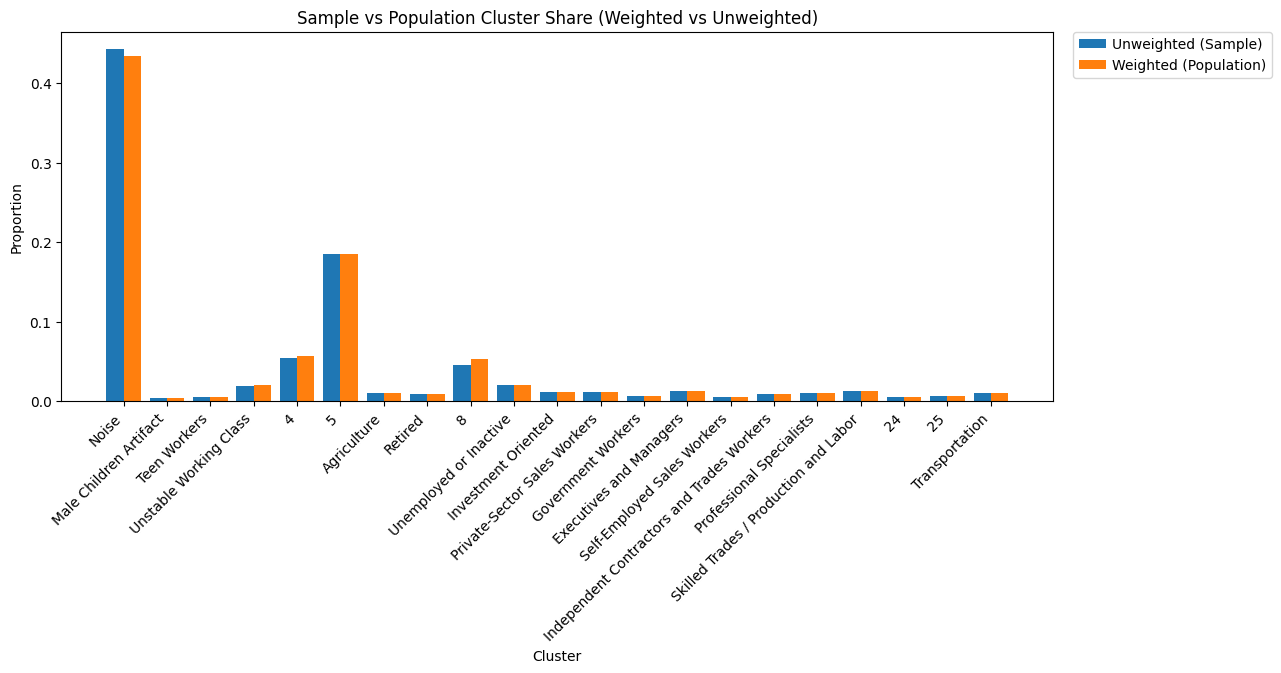

In [11]:
unweighted_sizes = (
	data_df["cluster"]
	.value_counts()
	.sort_index()
)

weighted_sizes = (
	data_df.groupby("cluster")[weight_column]
	.sum()
	.sort_index()
)

unweighted_prop = unweighted_sizes / unweighted_sizes.sum()
weighted_prop = weighted_sizes / weighted_sizes.sum()

def dict_getter(data):
	def getter(key):
		return data.get(key, key)
	return getter

df_plot = pd.DataFrame({
	"cluster": np.concatenate([
		pd.Index(unweighted_prop.index.values).map(dict_getter(cluster_labels)).values,
		pd.Index(weighted_prop.index.values).map(dict_getter(cluster_labels)).values
	]),
	"metric": (
		["Unweighted (Sample)"] * len(unweighted_prop)
		+ ["Weighted (Population)"] * len(weighted_prop)
	),
	"prop": np.concatenate([
		unweighted_prop.values,
		weighted_prop.values
	])
})

visualizations.grouped_bar_plot(
	df=df_plot,
	data_column="prop",
	group_column="cluster",
	label_column="metric",
	title="Sample vs Population Cluster Share (Weighted vs Unweighted)",
	xlabel="Cluster",
	ylabel="Proportion",
    figsize=(2*6.4, 4.8)
)

### Categorical Features

This section contains cluster-level summaries and visualizations of the categorical features used in the segmentation model. It focuses on understanding how discrete attributes are distributed across clusters and how these distributions differ between segments.

#### Categorical Summary Statistics

In [12]:
stats_df = data_df[categorical_columns + ["cluster"]].groupby("cluster").describe()

with pd.option_context("display.max_columns", None):
	display(stats_df)

class of worker                                                \
                  count unique                             top   freq   
cluster                                                                 
-1                88278      9                 Not in universe  80522   
 0                  858      1                 Not in universe    858   
 1                  830      6                         Private    732   
 2                 1103      7                         Private    929   
 3                 3854      8                         Private   2199   
 4                10900      4                         Private   9370   
 5                36951      7                         Private  26422   
 6                 2133      7                         Private    997   
 7                 2920      8                 Not in universe   2154   
 8                 9000      7                         Private   8264   
 9                 1283      3                 Not in universe   1272   
 10                7645      2                 Not in universe   7533   
 11                1353      2                 Not in universe   1350   
 12                4041      2                 Not in universe   3971   
 13                1906      2                 Not in universe   1903   
 14                2228      7                         Private   1381   
 15                2429      4                         Private   2414   
 16                 929      5              Federal government    923   
 17                1608      3                State government   1383   
 18                1361      4                Local government   1351   
 19                2632      7                         Private   2617   
 20                1077      3  Self-employed-not incorporated    662   
 21                1847      5  Self-employed-not incorporated   1842   
 22                1986      4                         Private   1960   
 23                3103      6                         Private   3063   
 24                1214      5                         Private   1201   
 25                1413      6                         Private   1393   
 26                2589      7                         Private   2542   
 27                2052      7                         Private   1836   

        education                                           marital stat  \
            count unique                         top   freq        count   
cluster                                                                    
-1          88278     17                    Children  46557        88278   
 0            858      1                    Children    858          858   
 1            830     10                  10th grade    335          830   
 2           1103      9                  10th grade    402         1103   
 3           3854     16        High school graduate    980         3854   
 4          10900     16        High school graduate   4303        10900   
 5          36951     16        High school graduate  12648        36951   
 6           2133     16        High school graduate    757         2133   
 7           2920     16        High school graduate   1060         2920   
 8           9000     16        High school graduate   3042         9000   
 9           1283     16        High school graduate    308         1283   
 10          7645     16        High school graduate   1461         7645   
 11          1353     16        High school graduate    290         1353   
 12          4041     17        High school graduate    592         4041   
 13          1906     14  Bachelors degree(BA AB BS)    581         1906   
 14          2228     16  Bachelors degree(BA AB BS)    860         2228   
 15          2429     16        High school graduate    726         2429   
 16           929     14        High school graduate    249          929   
 17          1608     15  Bachelors degree(BA AB BS)    429         1608   

#### Per Category Summaries

In [13]:
focused_clusters = [27]
focused_columns = None

for column in categorical_columns:
    if focused_columns is not None:
        if column not in focused_columns:
            continue
        
    table = pd.crosstab(
    	data_df["cluster"],
    	data_df[column],
    	normalize="index"
    ).mul(100)
    
    table.loc["Global"] = pd.crosstab(
    	index=pd.Series([0] * len(data_df)),
    	columns=data_df[column],
    	normalize="index"
    ).mul(100).iloc[0]
    
    table = table.reindex(["Global", *table.index.drop("Global")])
    if focused_clusters is not None:
        table = table.loc[focused_clusters]

        if len(focused_clusters) == 1:
            table = table.loc[:, table.loc[focused_clusters[0]].sort_values(ascending=False).index]
        	

    with pd.option_context("display.max_columns", None):
        display(
            HTML(f'<span style="color: red;">{column}</span>'),
            table
        )
        

class of worker,Private,Self-employed-not incorporated,Self-employed-incorporated,Local government,State government,Federal government,Without pay,Not in universe,Never worked
cluster,,,,,,,,,
27,89.473684,8.040936,0.925926,0.82846,0.438596,0.243665,0.048733,0.0,0.0


education,High school graduate,Some college but no degree,10th grade,11th grade,7th and 8th grade,Bachelors degree(BA AB BS),Associates degree-occup /vocational,9th grade,12th grade no diploma,5th or 6th grade,Associates degree-academic program,1st 2nd 3rd or 4th grade,Masters degree(MA MS MEng MEd MSW MBA),Prof school degree (MD DDS DVM LLB JD),Doctorate degree(PhD EdD),Less than 1st grade,Children
cluster,,,,,,,,,,,,,,,,,
27,54.97076,15.155945,5.750487,5.604288,4.580897,3.362573,2.777778,2.631579,1.803119,1.120858,1.120858,0.584795,0.292398,0.146199,0.048733,0.048733,0.0


marital stat,Married-civilian spouse present,Divorced,Separated,Widowed,Married-spouse absent,Married-A F spouse present,Never married
cluster,,,,,,,
27,79.191033,16.617934,2.14425,0.974659,0.877193,0.146199,0.048733


major industry code,Transportation,Retail trade,Construction,Wholesale trade,Manufacturing-durable goods,Manufacturing-nondurable goods,Business and repair services,Mining,Utilities and sanitary services,Agriculture,Personal services except private HH,Medical except hospital,Entertainment,Social services,Other professional services,Finance insurance and real estate,Education,Private household services,Hospital services,Communications,Armed Forces,Forestry and fisheries,Not in universe or children,Public administration
cluster,,,,,,,,,,,,,,,,,,,,,,,,
27,47.124756,9.844055,8.479532,8.430799,8.333333,7.651072,2.875244,2.339181,1.413255,0.877193,0.584795,0.292398,0.292398,0.292398,0.292398,0.292398,0.243665,0.194932,0.097466,0.048733,0.0,0.0,0.0,0.0


major occupation code,Transportation and material moving,Handlers equip cleaners etc,Professional specialty,Other service,Technicians and related support,Executive admin and managerial,Protective services,Not in universe,Machine operators assmblrs & inspctrs,Farming forestry and fishing,Armed Forces,Adm support including clerical,Precision production craft & repair,Private household services,Sales
cluster,,,,,,,,,,,,,,,
27,93.421053,6.140351,0.146199,0.097466,0.097466,0.048733,0.048733,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


race,White,Black,Other,Amer Indian Aleut or Eskimo,Asian or Pacific Islander
cluster,,,,,
27,87.816764,8.77193,1.413255,1.218324,0.779727


sex,Male,Female
cluster,,
27,99.610136,0.389864


family members under 18,Not in universe,Both parents present,Father only present,Mother only present,Neither parent present
cluster,,,,,
27,100.0,0.0,0.0,0.0,0.0


country of birth self,United-States,Mexico,Cuba,Puerto-Rico,Columbia,Canada,El-Salvador,Jamaica,Poland,Dominican-Republic,Haiti,England,Peru,Ecuador,Guatemala,Honduras,Nicaragua,Iran,Italy,Philippines,China,Vietnam,Trinadad&Tobago,India,Ireland,Greece,Germany,Hungary,Thailand,Laos,Portugal,Cambodia,France,Holand-Netherlands,Japan,Hong Kong,Outlying-U S (Guam USVI etc),Panama,Taiwan,South Korea,Scotland,Yugoslavia
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
27,92.860684,1.536936,0.6941,0.644522,0.545364,0.396629,0.34705,0.297471,0.297471,0.247893,0.247893,0.198314,0.198314,0.198314,0.198314,0.148736,0.099157,0.099157,0.099157,0.099157,0.049579,0.049579,0.049579,0.049579,0.049579,0.049579,0.049579,0.049579,0.049579,0.049579,0.049579,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Categorical Visualizations

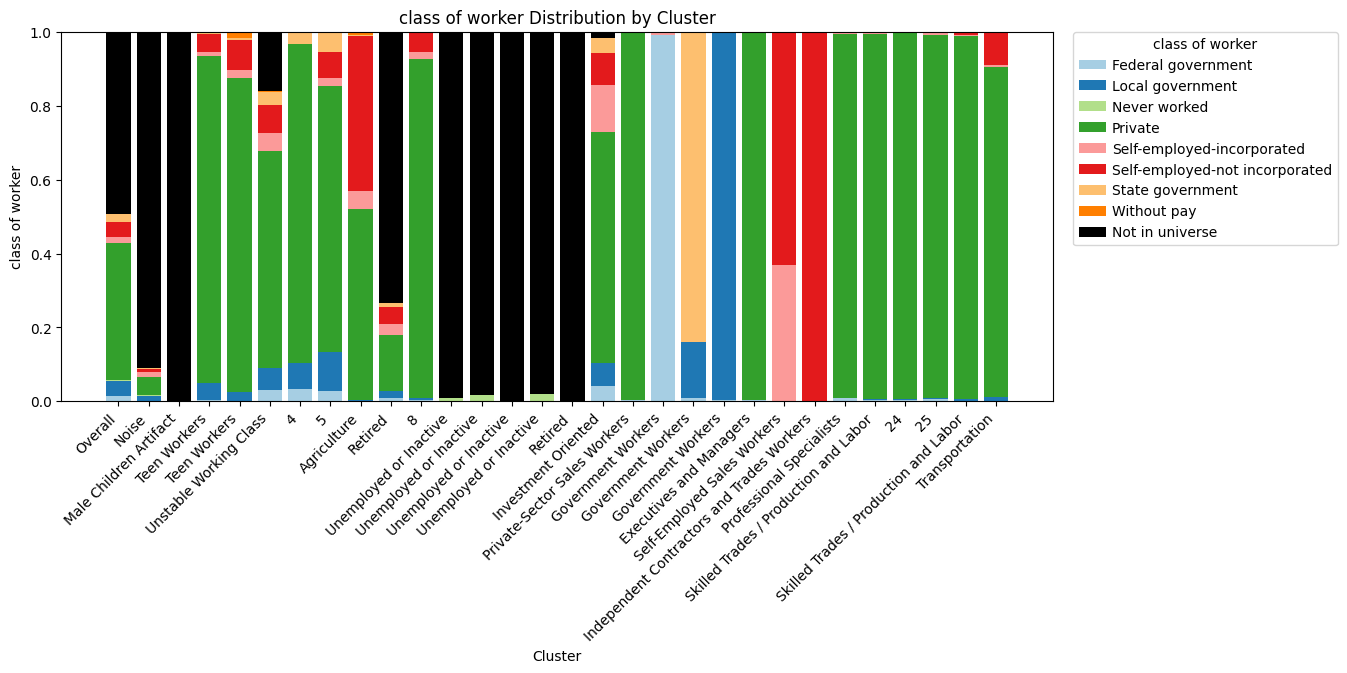

2026-06-24 15:41:59,166 - INFO - Saved figure to figures directory: /Users/jagraves21/census-income-ml-project/data/Census/figures/class_of_worker.png


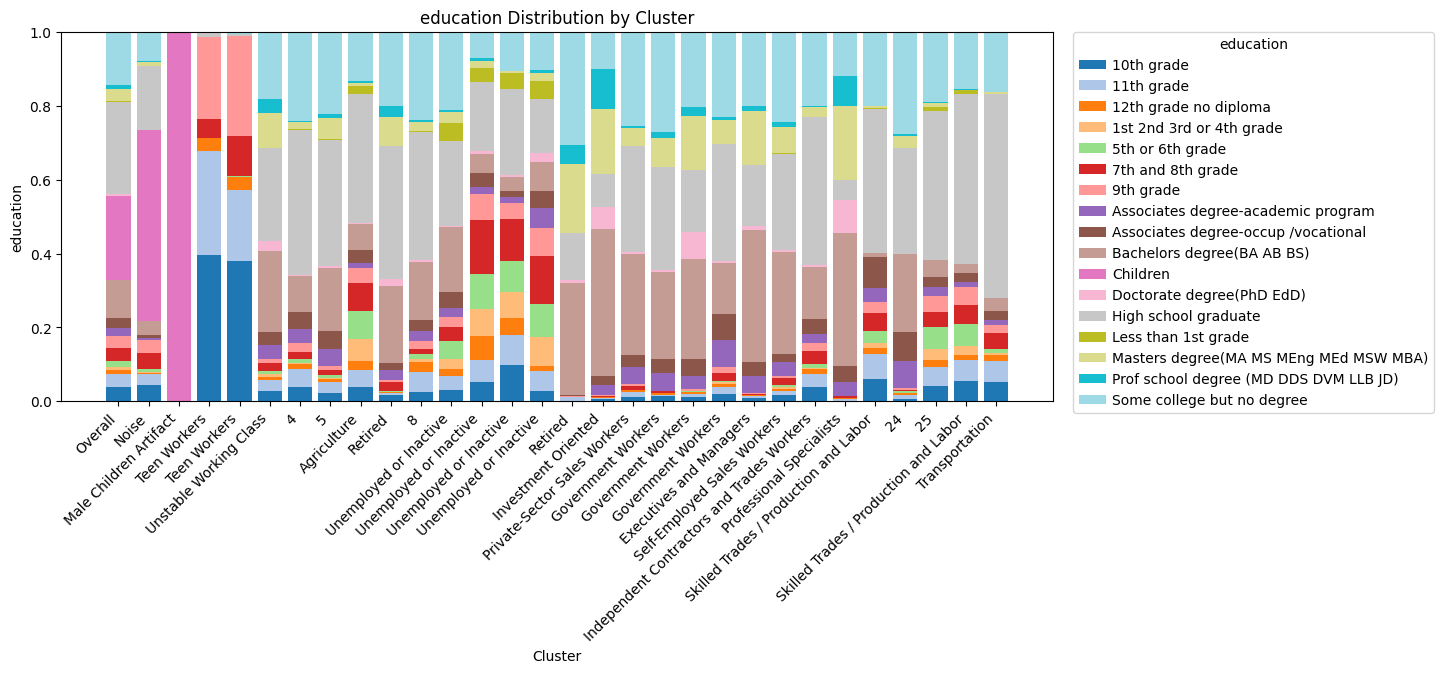

2026-06-24 15:42:00,441 - INFO - Saved figure to figures directory: /Users/jagraves21/census-income-ml-project/data/Census/figures/education.png


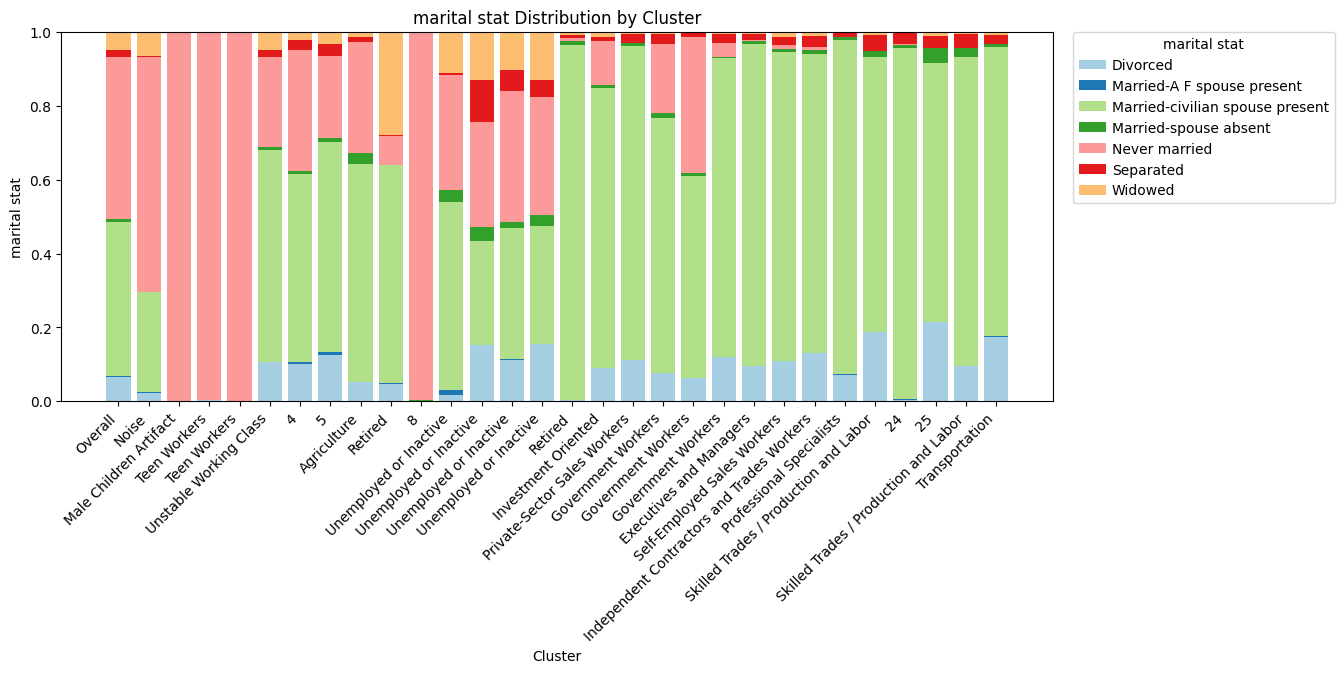

2026-06-24 15:42:01,541 - INFO - Saved figure to figures directory: /Users/jagraves21/census-income-ml-project/data/Census/figures/marital_stat.png


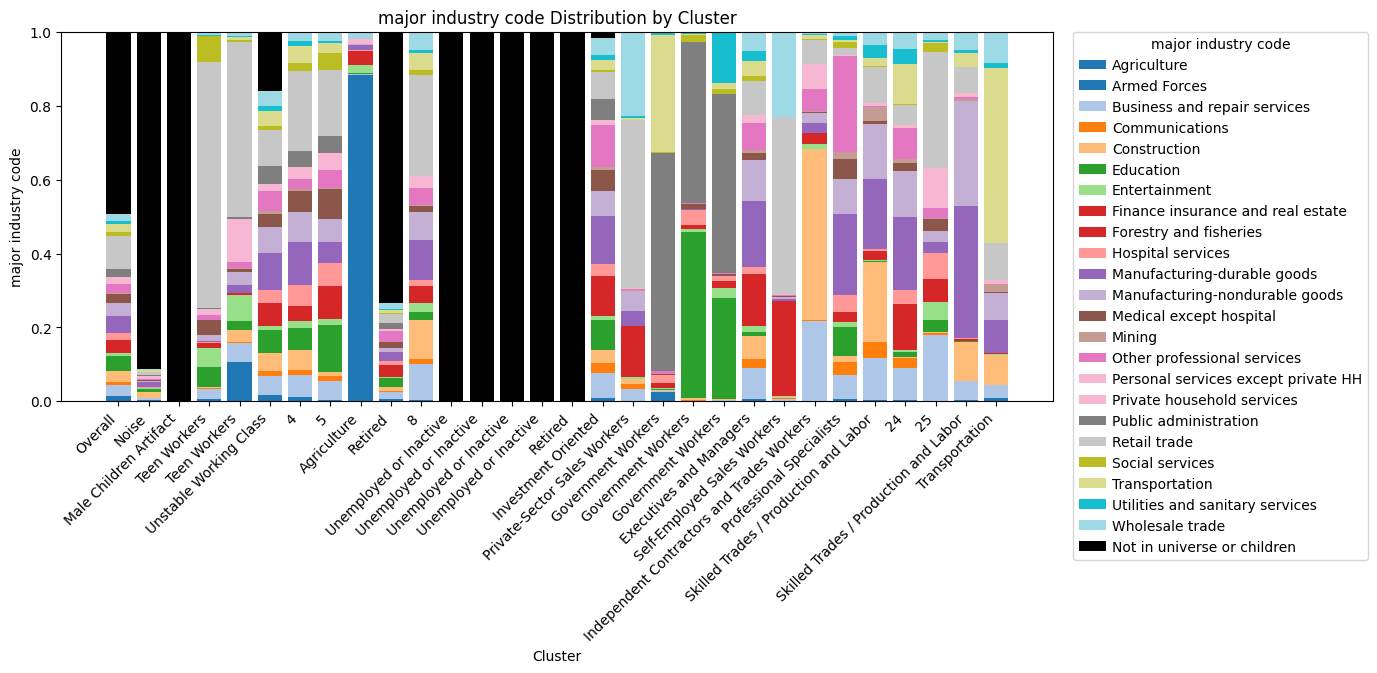

2026-06-24 15:42:03,114 - INFO - Saved figure to figures directory: /Users/jagraves21/census-income-ml-project/data/Census/figures/major_industry_code.png


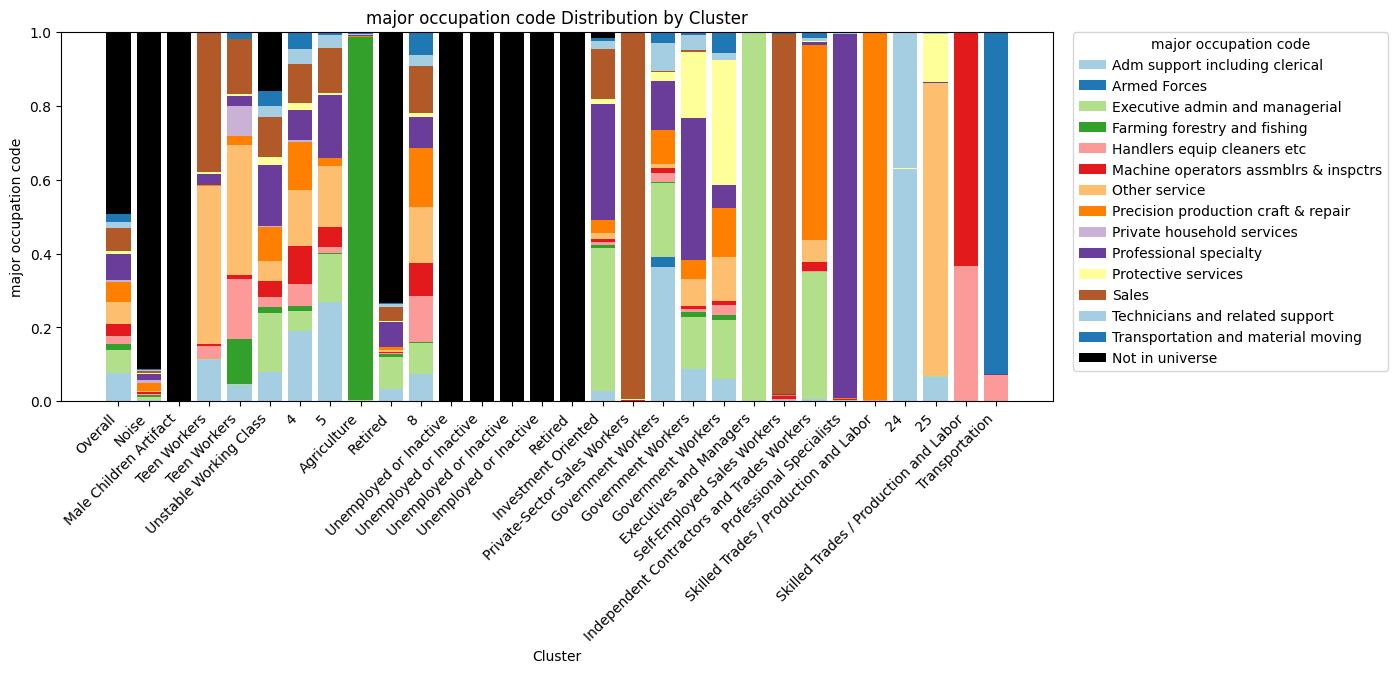

2026-06-24 15:42:04,287 - INFO - Saved figure to figures directory: /Users/jagraves21/census-income-ml-project/data/Census/figures/major_occupation_code.png


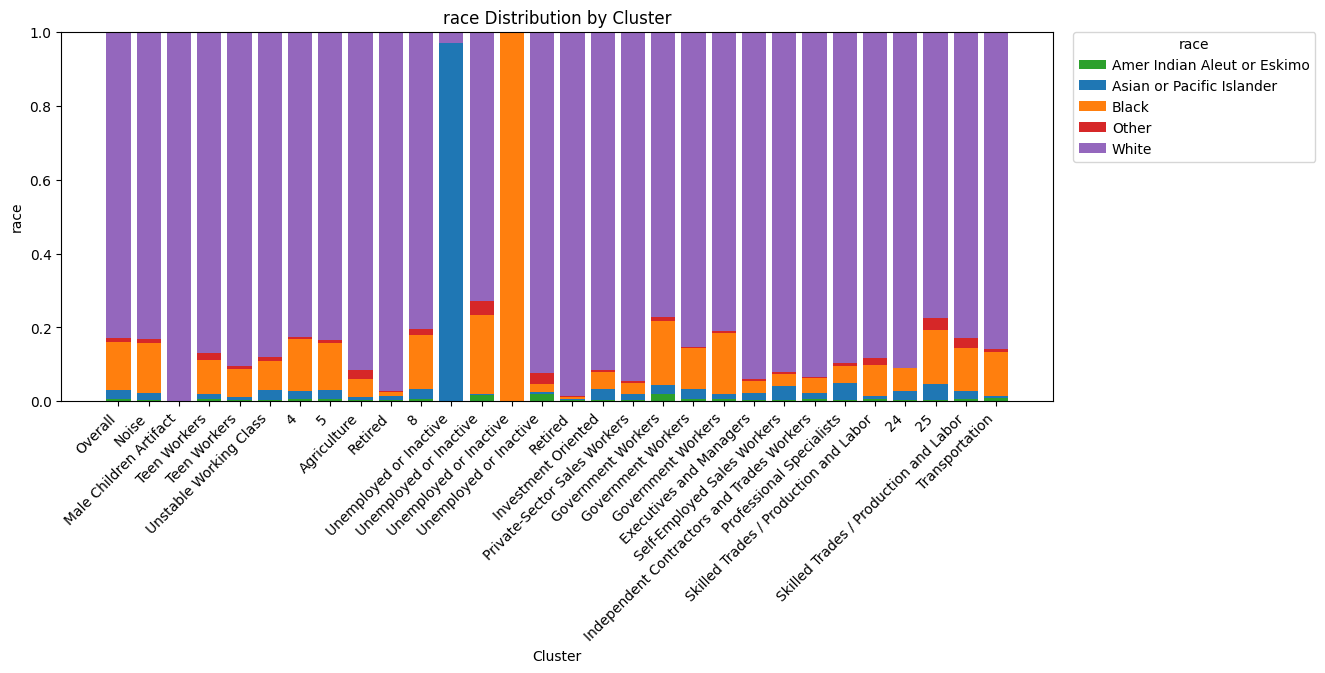

2026-06-24 15:42:04,984 - INFO - Saved figure to figures directory: /Users/jagraves21/census-income-ml-project/data/Census/figures/race.png


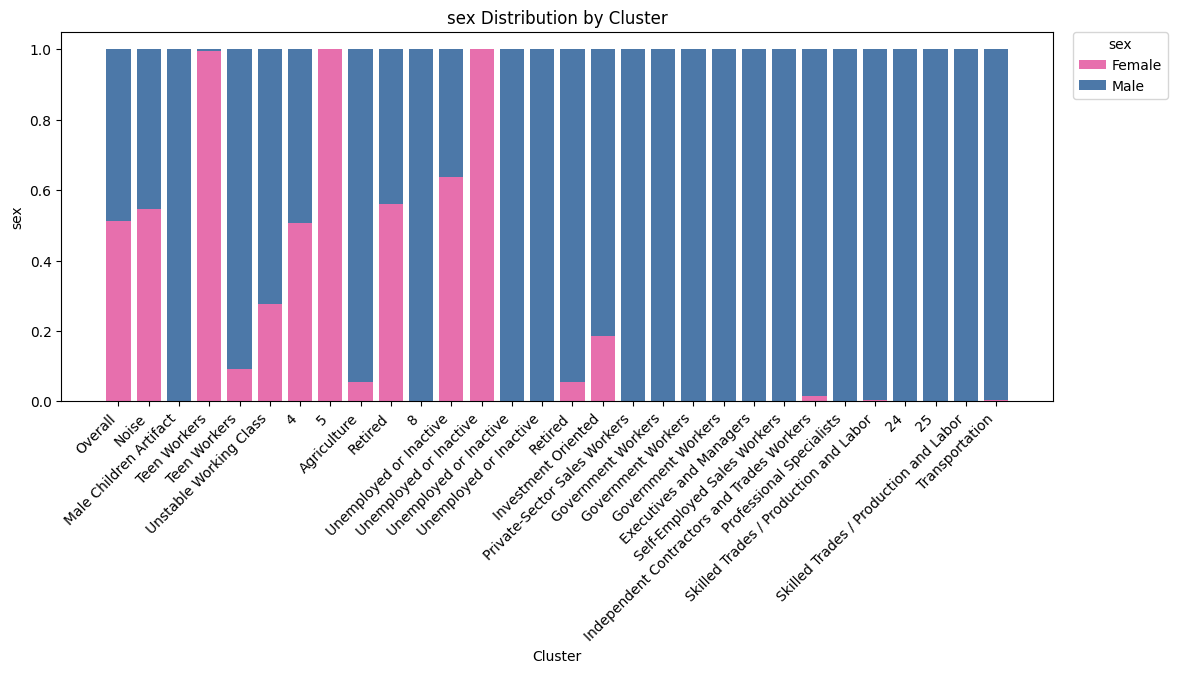

2026-06-24 15:42:05,544 - INFO - Saved figure to figures directory: /Users/jagraves21/census-income-ml-project/data/Census/figures/sex.png


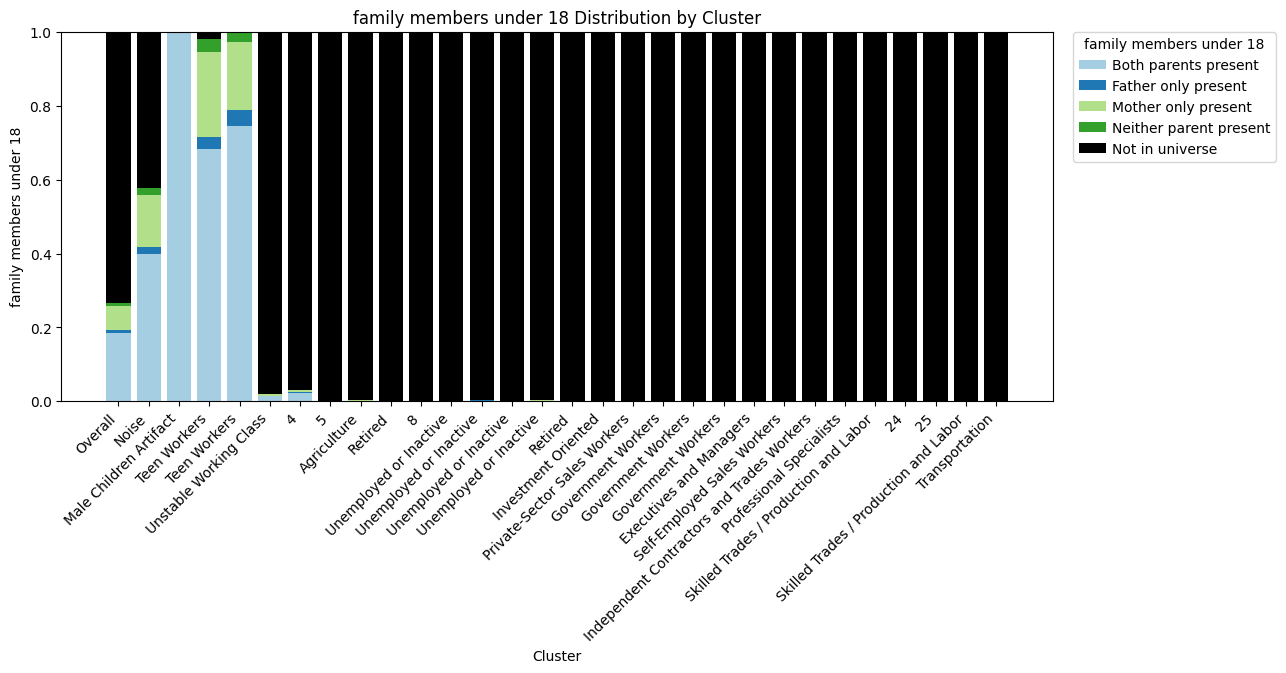

2026-06-24 15:42:06,268 - INFO - Saved figure to figures directory: /Users/jagraves21/census-income-ml-project/data/Census/figures/family_members_under_18.png


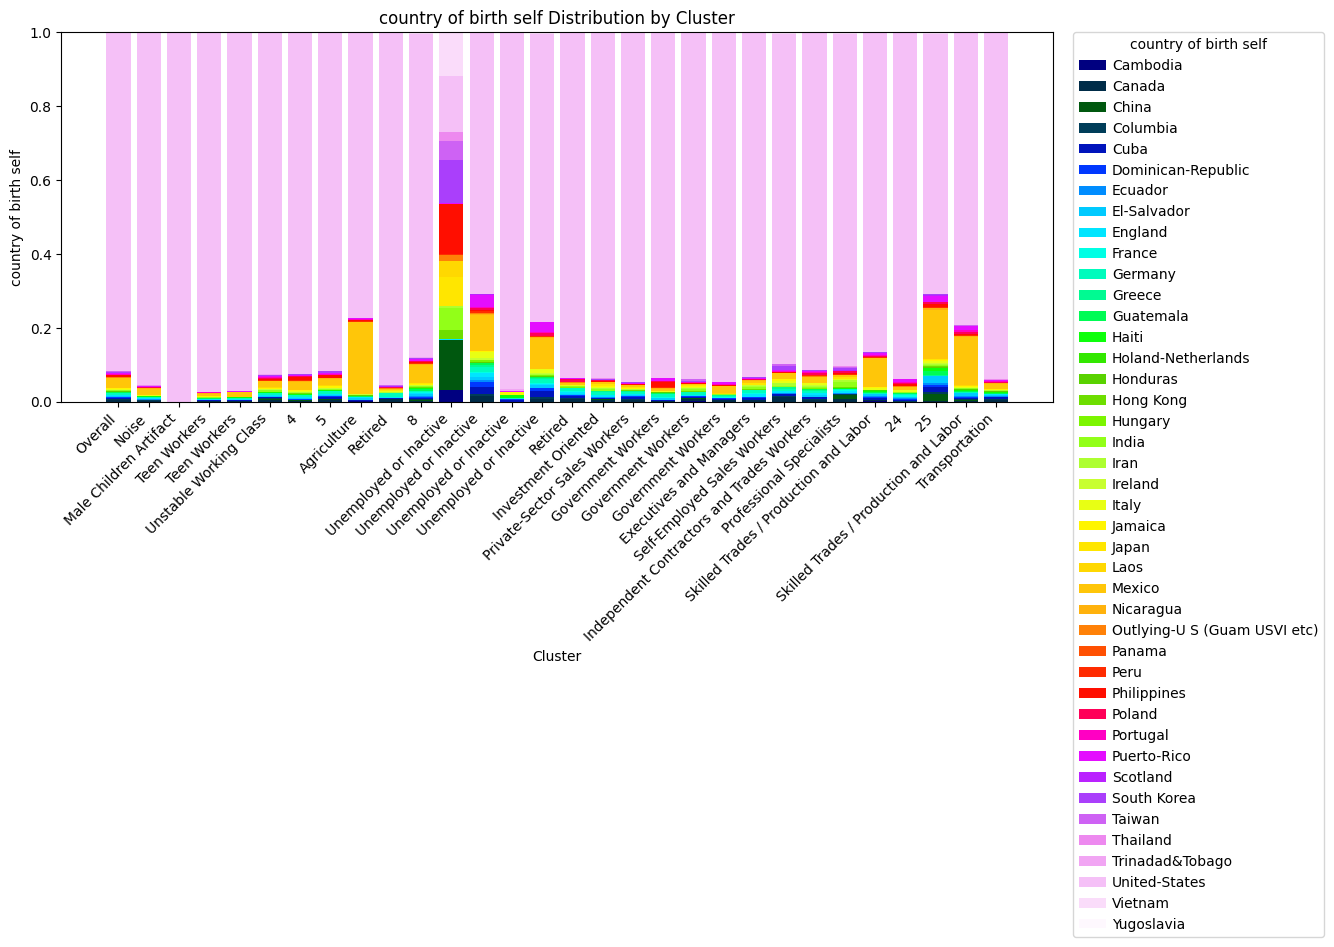

2026-06-24 15:42:08,535 - INFO - Saved figure to figures directory: /Users/jagraves21/census-income-ml-project/data/Census/figures/country_of_birth_self.png


In [14]:
visualizations.plot_cluster_features(
	data_df,
	cluster_assignments=data_df["cluster"],
    features=categorical_columns,
    weight_column=weight_column,
    niu_categories="default",
    treat_as_catagorical=numeric_categorical_features,
    cluster_labels=cluster_labels,
    bar_category_colors=bar_category_colors,
    violin_cluster_colors=violin_cluster_colors,
	figsize=(2*6.4, 4.8),
    save_fun=save_figure
)

### Numeric Features

#### Numeric Summary Statistics

In [15]:
stats_df = data_df[numeric_columns + ["cluster"]].groupby("cluster").describe().loc[[15]]

with pd.option_context("display.max_columns", None):
	display(stats_df)

age                                                      \
          count       mean        std   min   25%   50%   75%   max   
cluster                                                               
15       2429.0  41.912721  11.816686  18.0  33.0  40.0  50.0  90.0   

        wage per hour                                    capital gains  \
                count mean  std  min  25%  50%  75%  max         count   
cluster                                                                  
15             2429.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0        2429.0   

                                                              capital losses  \
               mean          std  min  25%  50%  75%      max          count   
cluster                                                                        
15       375.507616  1454.769225  0.0  0.0  0.0  0.0  10605.0         2429.0   

                                           dividends from stocks              \
        mean  std  min  25%  50%  75%  max                 count        mean   
cluster                                                                        
15       0.0  0.0  0.0  0.0  0.0  0.0  0.0                2429.0  114.729107   

                                                 
                std  min  25%  50%  75%     max  
cluster                                          
15       436.173382  0.0  0.0  0.0  0.0  4000.0

#### Numeric Visualizations

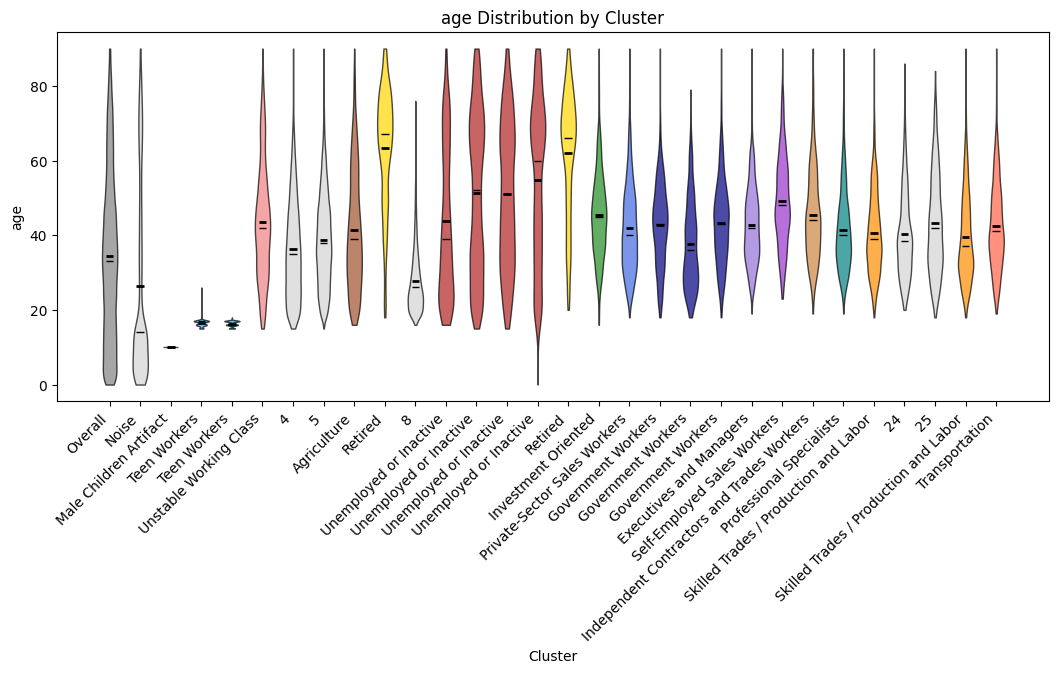

2026-06-24 15:42:09,827 - INFO - Saved figure to figures directory: /Users/jagraves21/census-income-ml-project/data/Census/figures/age.png


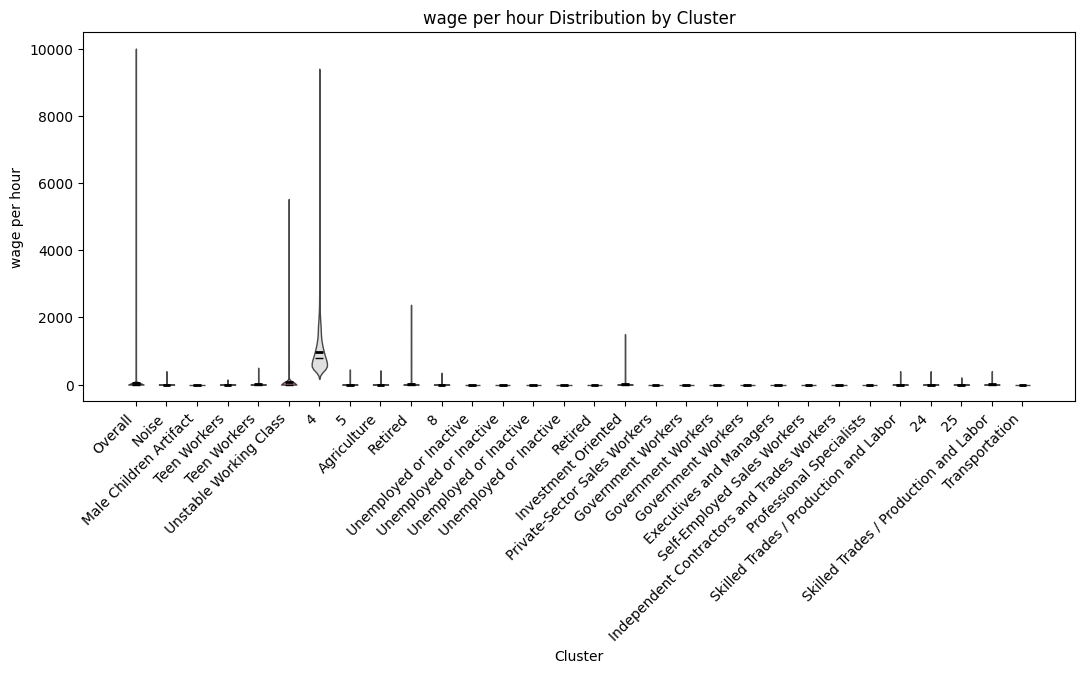

2026-06-24 15:42:10,999 - INFO - Saved figure to figures directory: /Users/jagraves21/census-income-ml-project/data/Census/figures/wage_per_hour.png


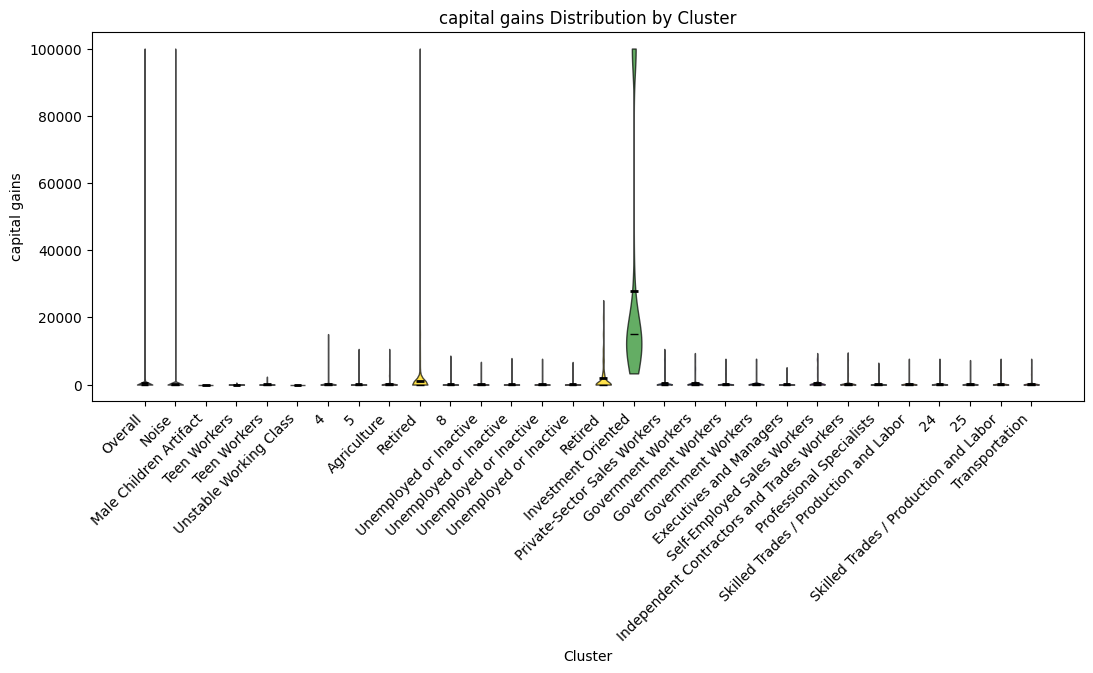

2026-06-24 15:42:11,883 - INFO - Saved figure to figures directory: /Users/jagraves21/census-income-ml-project/data/Census/figures/capital_gains.png


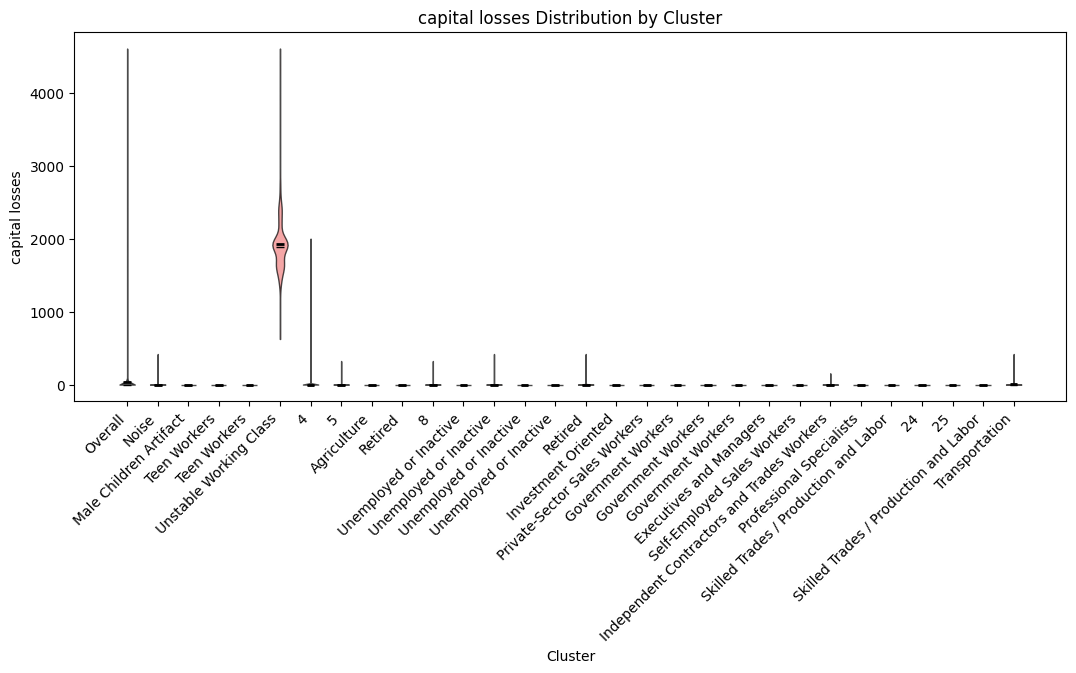

2026-06-24 15:42:12,697 - INFO - Saved figure to figures directory: /Users/jagraves21/census-income-ml-project/data/Census/figures/capital_losses.png


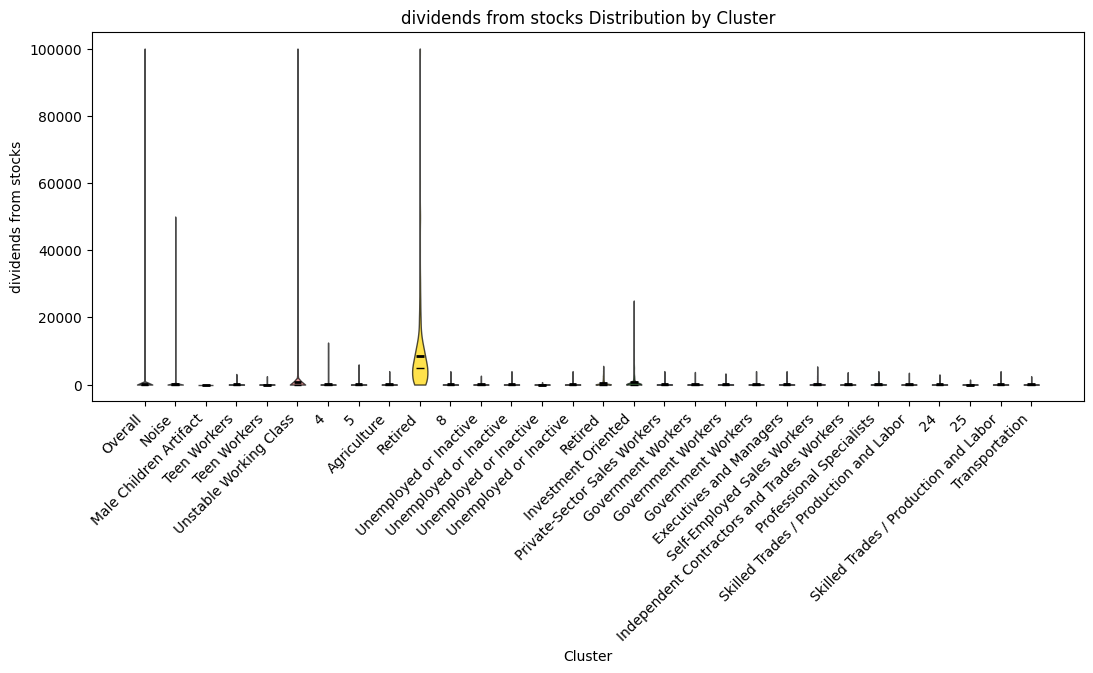

2026-06-24 15:42:13,564 - INFO - Saved figure to figures directory: /Users/jagraves21/census-income-ml-project/data/Census/figures/dividends_from_stocks.png


In [16]:
visualizations.plot_cluster_features(
	data_df,
	cluster_assignments=data_df["cluster"],
    features=numeric_columns,
    weight_column=weight_column,
    niu_categories="default",
    treat_as_catagorical=numeric_categorical_features,
    cluster_labels=cluster_labels,
    violin_cluster_colors=violin_cluster_colors,
	figsize=(2*6.4, 4.8),
    save_fun=save_figure
)